In [4]:
import pandas as pd
def load_prepare_data(path):
  """
  Función para cargar y procesar datos para el ejercicio.
  """
  df = pd.read_csv(path,sep=",")
  map_classes = {
    "religion":1,
    "age":1,
    "ethnicity":1,
    "gender":1,
    "other_cyberbullying":1,
    "not_cyberbullying":0,
  }
  df["cyberbullying"] = df.cyberbullying_type.map(map_classes)
  return df[["tweet_text","cyberbullying"]].copy()

# Ejercicio


En este ejercicio vamos a trabajar con un conjunto de datos procedente de medios sociales online.

Uno de los mayores problemas en el internet de hoy en día es la presencia de actitudes negativas hacia algunos colectivos en relación a su etnia, género, religión o ideología política. En este ejercicio trabajaremos con un conjunto de datos reales, etiquetados manualmente, procedentes de la plataforma [Kaggle](https://www.kaggle.com/datasets/andrewmvd/cyberbullying-classification/data). Originalmente, a cada documento del dataset se le asignó una de las siguientes categorías:
- *religion*
- *age*
- *ethnicity*
- *gender*
- *other_cyberbullying*
- *not_cyberbullying*


El objetivo inicial del dataset era su uso para entrenar un modelo capaz de detectar el tipo de contenido de odio presente en internet según el colectivo al que se atacaba. En este caso, para simplificar el ejercicio, se ha generado una función `load_prepare_data()` que cambia las categorías del dataset obteníendose al final 2 categorías con valor 1 o 0, indicando si el tweet tiene contenido de odio

Para el ejercicio debéis entrenar diferentes modelos de clasificación que permitan clasificar correctamente los tweets. Para ello será necesario crear y utilizar funciones de preprocesado de datos similares a las vistas en clase, aplicar estrategias de vectorización de trextos como TF-IDF o embeddings, y entrenar/evaluar modelos de clasificación. Para que os sirva de orientación, los criterios de evaluación del ejercicio serán los siguientes:

-	**Análisis exploratorio, pre-procesado y normalización de los datos (30%)**:
        -	El ejercicio deberá contener un análisis exploratorio de los datos como número de documentos, gráficas de distribución de longitudes y/o wordclouds, entre otros análisis que se os pudieran ocurrir. Vuestros ejercicios deberán incorporar al menos los análisis exploratorios vistos en clase.

    -	También tendréis que tener funciones para normalizar textos que permitan eliminar palabras vacías, quitar símbolos de puntuación y lematizar o hacer stemming.  

-	**Vectorización de textos (40%)**

    En clase hemos visto diferentes estrategias de vectorización como TF-IDF y Word Embeddings. Será necesario incorporar características adicionales como el sentimiento o características léxicas.

-	**Entrenamiento y validación del sistema (30%)**
  -	En el proceso de entrenamiento del modelo tendréis que testear al menos 3 modelos de clasificación. El procedimiento debe ser similar al visto en clase, en el que primero estimábamos el rendimiento de varios algoritmos de forma general, para posteriormente seleccionar el mejor para ajustar los hiperparámetros.


**Nota 1**: El ejercicio propuesto es similar a los ejercicios de clasificación visto en clase, por lo que es importante que documentéis y expliquéis adecuadamente (con vuestras palabras) los procesos llevados a cabo en el ejercicio. No hacerlo puede llegar a penalizar hasta 1 punto en la calificación final.

**Nota 2**: Cualquier cálculo adicional a los vistos en clase (visualizaciones, nuevas características añadidas al modelo...) será valorado positivamente en la calificación.

## 0. Imports


In [5]:
import pandas as pd

## 1. Obtención del corpus
Para la obtención de los datos teneis disponible la función `load_prepare_data()`. Esta función prepara los datos del ejercicio en formato Pandas dataframe para que podais realizarlo.

In [6]:
path_data = "https://raw.githubusercontent.com/luisgasco/ntic_master_datos/main/datasets/cyberbullying_tweets.csv"
# Path de datos alternativos en caso de que el anterior no funcione (al estar alojado en github puede haber limitaciones
# en la descarga.
# path_data = "https://zenodo.org/records/10938455/files/cyberbullying_tweets.csv?download=1"
dataset = load_prepare_data(path_data)

In [7]:
dataset.head(4)

,tweet_text,cyberbullying
0,"In other words #katandandre, your food was cra...",0
1,Why is #aussietv so white? #MKR #theblock #ImA...,0
2,@XochitlSuckkks a classy whore? Or more red ve...,0
3,"@Jason_Gio meh. :P thanks for the heads up, b...",0


In [8]:
!pip install contractions

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import string
import re
import contractions
from tqdm.autonotebook import tqdm
tqdm.pandas()

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.metrics import classification_report

<ipython-input-8-ce291d227921>:10: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


## 2. Análisis exploratorio

In [9]:
print("Existen {} documentos duplicadas".format(np.sum(dataset.duplicated())))

Existen 166 documentos duplicadas


In [10]:
# Quitaremos esos duplicados
dataset = dataset.drop_duplicates()
print("Despues de quitar duplicados tenemos un conjunto de {} documentos".format(dataset.shape[0]))

Despues de quitar duplicados tenemos un conjunto de 47526 documentos


In [11]:
print("Hay {} valores vacíos en las noticias y {} valores vacíos en las etiquetas en los datos".format(np.sum(dataset.isnull())[0],
                                                                                                        np.sum(dataset.isnull())[1]))

Hay 0 valores vacíos en las noticias y 0 valores vacíos en las etiquetas en los datos


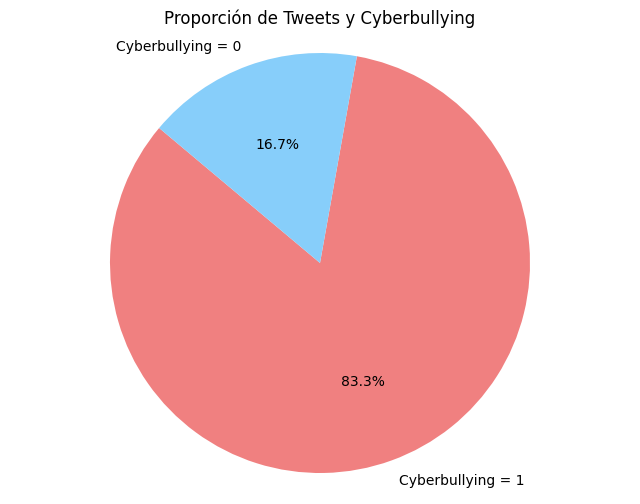

In [12]:
from matplotlib import pyplot as plt

# Contar la cantidad de tweets en cada categoría de "cyberbullying"
cantidad_cyberbullying_1 = len(dataset[dataset['cyberbullying'] == 1])
cantidad_cyberbullying_0 = len(dataset[dataset['cyberbullying'] == 0])

# Preparar datos para el gráfico de tarta
labels = ['Cyberbullying = 1', 'Cyberbullying = 0']
sizes = [cantidad_cyberbullying_1, cantidad_cyberbullying_0]

# Crear el gráfico de tarta
plt.figure(figsize=(8, 6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140, colors=['lightcoral', 'lightskyblue'])
plt.title('Proporción de Tweets y Cyberbullying')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()


In [13]:
dataset["char_len"] = dataset["tweet_text"].apply(lambda x: len(x))


<Figure size 1400x1200 with 0 Axes>

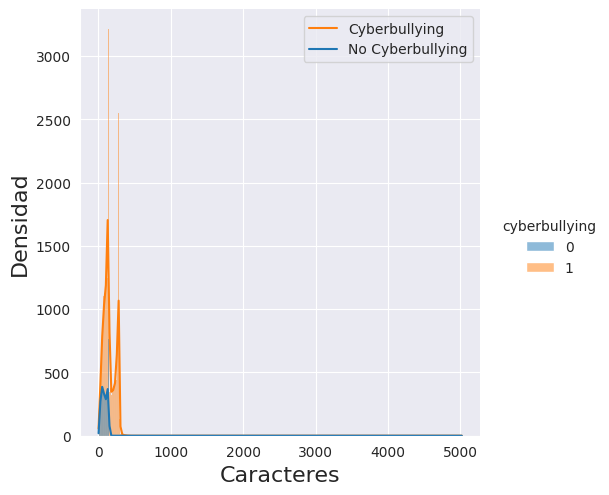

In [14]:
# Importamos las librerías matplotlib y seaborn:
import matplotlib.pyplot as plt
import seaborn as sns

fig = plt.figure(figsize=(14,12))
sns.set_style("darkgrid")

sns.displot(data=dataset, x="char_len", hue="cyberbullying", kde=True, legend=True)
plt.legend(["Cyberbullying", "No Cyberbullying"])
# Definimos el título de los ejes:
plt.xlabel('Caracteres', fontsize=16)
plt.ylabel('Densidad', fontsize=16)

# Finalmente mostramos el gráfico:
plt.show()
#No se aprecia bien, posteriormente le hacemos zoom

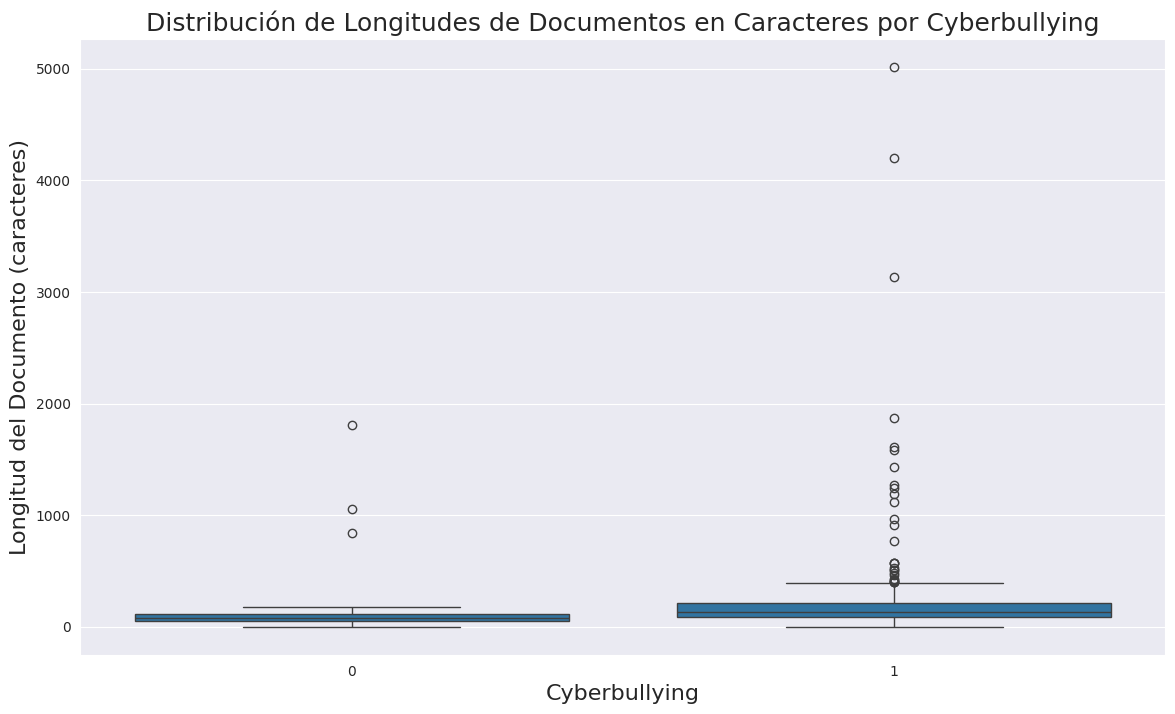

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Establecer el estilo de los gráficos
sns.set_style("darkgrid")

# Crear la figura y el eje
plt.figure(figsize=(14, 8))

# Generar el boxplot
sns.boxplot(x="cyberbullying", y="char_len", data=dataset)

# Definir el título de los ejes
plt.xlabel('Cyberbullying', fontsize=16)
plt.ylabel('Longitud del Documento (caracteres)', fontsize=16)
plt.title('Distribución de Longitudes de Documentos en Caracteres por Cyberbullying', fontsize=18)

# Mostrar el gráfico
plt.show()

#Mas valores atipicos altos en los casos de cyberbullying, aunque como hemos visto anteriormente también hay una mayor cantidad

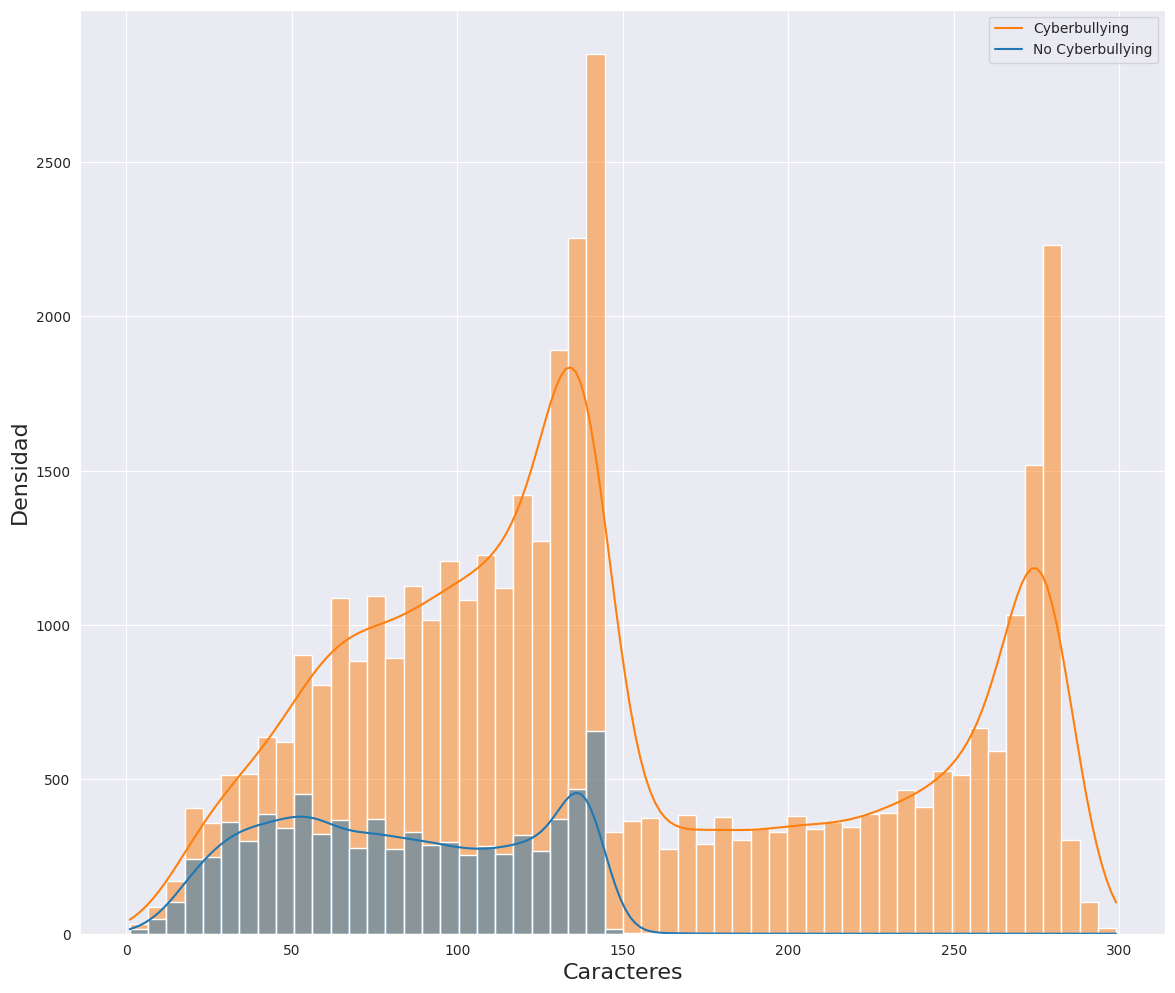

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filtrar el dataset para incluir solo tweets con menos de 300 caracteres
subset_dataset = dataset[dataset['char_len'] < 300]

# Establecer el estilo de los gráficos
sns.set_style("darkgrid")

# Crear la figura y el eje
fig = plt.figure(figsize=(14, 12))

# Generar el gráfico de distribución
sns.histplot(data=subset_dataset, x="char_len", hue="cyberbullying", kde=True, legend=True)

# Definir la leyenda
plt.legend(["Cyberbullying", "No Cyberbullying"])

# Definir el título de los ejes
plt.xlabel('Caracteres', fontsize=16)
plt.ylabel('Densidad', fontsize=16)

# Mostrar el gráfico
plt.show()
#Los no cyberbullying se concentran en 150 caracteres o menos, habiendo 2 picos en 150 y llegando a 300 en el otro caso.

In [17]:
!pip install wordcloud
from wordcloud import WordCloud

In [18]:
# Obtener los textos asociados a la categoría 0 (no cyberbullying)
txt_cat0 = ",".join(dataset[dataset['cyberbullying'] == 0]['tweet_text'].to_list())

# Obtener los textos asociados a la categoría 1 (cyberbullying)
txt_cat1 = ",".join(dataset[dataset['cyberbullying'] == 1]['tweet_text'].to_list())


In [19]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
en_stopwords = stopwords.words('english') # 'english'

wordcloud = WordCloud(background_color="white", max_words=5000, contour_width=0,
                      contour_color='steelblue', stopwords=en_stopwords,
                      normalize_plurals = True)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


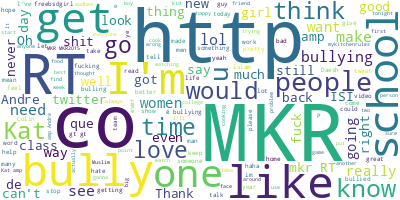

In [20]:
# Genera el wordcloud
wordcloud.generate(txt_cat0)
# Visualizalo en una imagen
wordcloud.to_image()

#No hay nada ofensivo, solo mencionan bullying, class, parece información sin cyberacoso

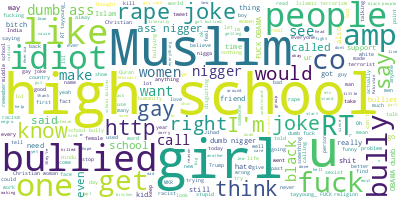

In [21]:
# Genera el wordcloud
wordcloud.generate(txt_cat1)
# Visualizalo en una imagen
wordcloud.to_image()
#Hay insultos y palabras mal sonantes

## 3. Preprocesado y Normalización

In [22]:
#Como gusto personal me gusta ver los trigramas y bigramas antes y después del procesado porque me ayuda a verificar que todo se esta haciendo correctamente.
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Crear un vectorizador para bigramas
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)

# Ajustar y transformar los datos del texto
X_bigrams = vectorizer.fit_transform(dataset['tweet_text'])

# Crear un DataFrame con los bigramas más comunes
bigram_df = pd.DataFrame(X_bigrams.toarray(), columns=vectorizer.get_feature_names_out())

# Sumar las ocurrencias de cada bigrama
bigram_counts = bigram_df.sum().sort_values(ascending=False)

# Mostrar los bigramas más comunes
print("Bigramas más comunes (incluyendo stopwords):")
print(bigram_counts)


Bigramas más comunes (incluyendo stopwords):
high school       4708
in high           2533
http co           2371
in the            2300
of the            2008
to be             1778
dumb ass          1552
you re            1523
rape jokes        1472
you are           1376
bullied me        1324
if you            1307
ass nigger        1224
me in             1092
this is           1086
fuck obama         995
to the             982
obama dumb         967
who bullied        959
tayyoung_ fuck     956
dtype: int64


In [23]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Crear un vectorizador para trigramas
vectorizer = CountVectorizer(ngram_range=(3, 3), max_features=20)

# Ajustar y transformar los datos del texto
X_trigrams = vectorizer.fit_transform(dataset['tweet_text'])

# Crear un DataFrame con los trigramas más comunes
trigram_df = pd.DataFrame(X_trigrams.toarray(), columns=vectorizer.get_feature_names_out())

# Sumar las ocurrencias de cada trigram
trigram_counts = trigram_df.sum().sort_values(ascending=False)

# Mostrar los trigramas más comunes
print("Trigramas más comunes (incluyendo stopwords):")
print(trigram_counts)

# Apreciamos un exceso de stopwords

Trigramas más comunes (incluyendo stopwords):
in high school          2504
dumb ass nigger         1138
fuck obama dumb          966
obama dumb ass           964
tayyoung_ fuck obama     956
bullied me in            820
me in high               756
who bullied me           670
not sexist but           482
rt tayyoung_ fuck        456
girls who bullied        438
girl who bullied         367
high school and          358
bullied in high          356
dumb as fuck             312
one of the               304
that bullied me          291
in middle school         265
you dumb nigger          256
the girls who            248
dtype: int64


In [24]:
# Eliminar espacios
def eliminar_espacios(text):
    return  " ".join(text.split())

# To lower
def texto_to_lower(text):
  return text.lower()

In [25]:
dataset["tweet_text"] = dataset["tweet_text"].progress_apply(eliminar_espacios)
dataset["tweet_text"] = dataset["tweet_text"].progress_apply(texto_to_lower)


  0%|          | 0/47526 [00:00<?, ?it/s]

  0%|          | 0/47526 [00:00<?, ?it/s]

In [26]:
# Reemplazar contractions usando la librería "contractions" https://github.com/kootenpv/contractions
def replace_contraction(text):
    return contractions.fix(text, slang=True)

In [27]:
dataset["tweet_text"] = dataset["tweet_text"].progress_apply(lambda x: replace_contraction(x))

  0%|          | 0/47526 [00:00<?, ?it/s]

In [28]:
# Tokenizador
from nltk.tokenize import TweetTokenizer
tweet_tokenizer = TweetTokenizer()

def normalizar_tokens(documento):
    # Dividir el documento en palabras
    palabras = tweet_tokenizer.tokenize(documento)

    # Reemplazar URLs, menciones de Twitter y números por los tokens correspondientes
    for i in range(len(palabras)):
        if palabras[i].startswith("http://") or palabras[i].startswith("https://") or palabras[i].startswith("www."):
            palabras[i] = "URL"
        elif palabras[i].startswith("@"):
            palabras[i] = "MENTION"
        elif palabras[i].isdigit():
            palabras[i] = "NUM"

    # Unir las palabras de nuevo en un documento modificado
    documento_modificado = ' '.join(palabras)

    return documento_modificado


In [29]:
dataset["tweet_text"] = dataset["tweet_text"].progress_apply(lambda x: normalizar_tokens(x))

  0%|          | 0/47526 [00:00<?, ?it/s]

In [30]:
import spacy
nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner'])

def lematizar_eliminacion_tokens(texto):
    # Procesar el texto con el objeto nlp
    doc = nlp(texto)

    # Lematizar el texto
    lemas = [token.lemma_ for token in doc]

    # Eliminar símbolos de puntuación y stopwords
    tokens_filtrados = [token for token in lemas if token.isalpha() and token.lower() not in en_stopwords]

    # Unir los tokens filtrados en un nuevo texto
    texto_procesado = ' '.join(tokens_filtrados)

    return texto_procesado

In [31]:
dataset["tweet_text"] = dataset["tweet_text"].progress_apply(lambda x: lematizar_eliminacion_tokens(x))

  0%|          | 0/47526 [00:00<?, ?it/s]

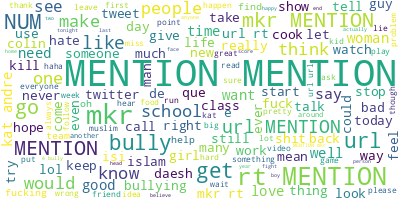

In [32]:
txt_cat0 = ",".join(dataset[dataset.cyberbullying==0].tweet_text.to_list())
txt_cat1 = ",".join(dataset[dataset.cyberbullying==1].tweet_text.to_list())
#
# Genera el wordcloud
wordcloud.generate(txt_cat0)
# Visualizalo en una imagen
wordcloud.to_image()

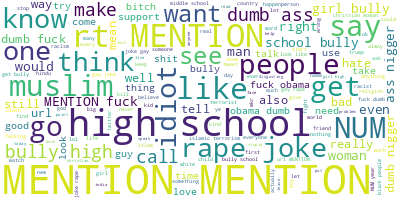

In [33]:
# Genera el wordcloud
wordcloud.generate(txt_cat1)
# Visualizalo en una imagen
wordcloud.to_image()

#Notamos una gran cantidad de menciones y muchos insultos en casos de cyberbullying

In [34]:
def token_appearance(document, token = "MENTION"):
  return len([x for x in document.split() if x == token])

In [35]:
dataset

,tweet_text,cyberbullying,char_len
0,word katandandre food crapilicious mkr,0,61
1,aussietv white mkr theblock imacelebrityau tod...,0,115
2,MENTION classy whore red velvet cupcake,0,60
3,MENTION meh thank head concerned another angry...,0,103
4,MENTION isis account pretend kurdish account l...,0,103
...,...,...,...
47687,black people expect anything depend anything y...,1,234
47688,turner withhold disappointment turner call cou...,1,276
47689,swear god dumb nigger bitch get bleach hair re...,1,104
47690,yea fuck rt MENTION nigger fucking unfollow fu...,1,90


In [36]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

# Cargar el conjunto de datos
# Suponiendo que dataset es tu DataFrame con una columna llamada 'tweet_text'
# dataset = ...

# Eliminar las stopwords del texto
stop_words = set(stopwords.words('english'))
dataset['tweet_text'] = dataset['tweet_text'].apply(lambda x: ' '.join([word for word in x.split() if word.lower() not in stop_words]))



[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [37]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import WordNetLemmatizer
import nltk
nltk.download('punkt')
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()


def lemmatize_text(text):
    try:

        words = nltk.word_tokenize(text)


        lemmatized_words = [lemmatizer.lemmatize(word) for word in words
                           if word.isalpha()]


        lemmatized_text = ' '.join(lemmatized_words)
        return lemmatized_text
    except Exception as e:
        print(f"Error lemmatizing text: {e}")
        return text


dataset['tweet_text'] = dataset['tweet_text'].apply(lemmatize_text)

#Lematizamos y quitamos stopwords por que son palabras que no aportan nada, y las palabras de la misma familia o distinto tiempo verbal las unificamos para que el programa entienda mejor a la hora de vectorizar

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [38]:
# Crear un vectorizador para bigramas
vectorizer = CountVectorizer(ngram_range=(2, 2), max_features=20)

# Ajustar y transformar los datos del texto
X_bigrams = vectorizer.fit_transform(dataset['tweet_text'])

# Crear un DataFrame con los bigramas más comunes
bigram_df = pd.DataFrame(X_bigrams.toarray(), columns=vectorizer.get_feature_names_out())

# Sumar las ocurrencias de cada bigrama
bigram_counts = bigram_df.sum().sort_values(ascending=False)

# Mostrar los bigramas más comunes
print("Bigramas más comunes sin stopwords:")
print(bigram_counts)

#Notable mejoría aunque para ser honesto podría ser mejorado unificando bully bullied etc

Bigramas más comunes sin stopwords:
mention mention      7346
high school          4715
rt mention           4208
rape joke            2280
dumb as              1570
bully high           1562
school bully         1484
girl bully           1443
mention fuck         1434
as nigger            1324
dumb nigger          1186
dumb fuck            1075
fuck obama           1000
obama dumb            987
islamic terrorism     861
christian woman       836
get bully             823
gay joke              804
fuck dumb             705
num year              668
dtype: int64


In [39]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

# Crear un vectorizador para trigramas
vectorizer = CountVectorizer(ngram_range=(3, 3), max_features=20)  # max_features ajusta el número de trigramas más comunes que deseas extraer

# Ajustar y transformar los datos del texto
X_trigrams = vectorizer.fit_transform(dataset['tweet_text'])

# Crear un DataFrame con los trigramas más comunes
trigram_df = pd.DataFrame(X_trigrams.toarray(), columns=vectorizer.get_feature_names_out())

# Sumar las ocurrencias de cada trigram
trigram_counts = trigram_df.sum().sort_values(ascending=False)

# Mostrar los trigramas más comunes
print("Trigramas más comunes:")
print(trigram_counts)


Trigramas más comunes:
mention mention mention    2751
bully high school          1550
dumb as nigger             1204
fuck obama dumb             980
mention fuck obama          972
obama dumb as               966
girl bully high             835
rt mention mention          745
high school bully           646
rt mention fuck             531
girl high school            415
fuck dumb nigger            388
make rape joke              350
gay rape joke               303
rt mention sexist           284
rape joke gay               266
high school girl            212
mention mention fuck        209
num year old                205
joke gay joke               194
dtype: int64


In [40]:
import re

# Expresión regular para detectar emoticonos
emoji_pattern = re.compile(
    "["
    u"\U0001F600-\U0001F64F"  # Emoticonos
    u"\U0001F300-\U0001F5FF"  # Símbolos y pictogramas
    u"\U0001F680-\U0001F6FF"  # Transportes y signos
    u"\U0001F700-\U0001F77F"  # Otros símbolos y pictogramas
    u"\U0001F780-\U0001F7FF"  # Geométricos suplementarios
    u"\U0001F800-\U0001F8FF"  # Flechas suplementarias
    u"\U0001F900-\U0001F9FF"  # Rostros y objetos adicionales
    u"\U0001FA00-\U0001FA6F"  # Otros pictogramas adicionales
    u"\U0001FA70-\U0001FAFF"  # Otros pictogramas adicionales
    u"\U00002702-\U000027B0"  # Otros pictogramas adicionales
    u"\U000024C2-\U0001F251"
    "]+",
    flags=re.UNICODE
)

# Función para detectar emoticonos en un texto
def contiene_emoticonos(texto):
    return bool(emoji_pattern.search(texto))

# Aplicar la función a la columna 'tweet_text'
dataset['contiene_emoticonos'] = dataset['tweet_text'].apply(contiene_emoticonos)

# Mostrar la cantidad de documentos con emoticonos
num_con_emoticonos = dataset['contiene_emoticonos'].sum()
print(f"Existen {num_con_emoticonos} documentos que contienen emoticonos.")


Existen 23 documentos que contienen emoticonos.


In [41]:
# Contar la cantidad de documentos con emoticonos y cyberbullying = 1
num_con_emoticonos_cyberbullying_1 = dataset[(dataset['contiene_emoticonos'] == True) & (dataset['cyberbullying'] == 1)].shape[0]

# Contar la cantidad de documentos con emoticonos y cyberbullying = 0
num_con_emoticonos_cyberbullying_0 = dataset[(dataset['contiene_emoticonos'] == True) & (dataset['cyberbullying'] == 0)].shape[0]

print(f"Existen {num_con_emoticonos_cyberbullying_1} documentos con emoticonos y cyberbullying = 1.")
print(f"Existen {num_con_emoticonos_cyberbullying_0} documentos con emoticonos y cyberbullying = 0.")


Existen 20 documentos con emoticonos y cyberbullying = 1.
Existen 3 documentos con emoticonos y cyberbullying = 0.


In [42]:
# Guardamos el DataFrame como archivo CSV para no tener que preprocesar y normalizar por si nos da algún error
dataset.to_csv('dataset.csv', index=False)



In [43]:
import pandas as pd
dataset = pd.read_csv('dataset.csv')

# Mostrar el DataFrame cargado
print(dataset)

                                              tweet_text  cyberbullying  \
0                 word katandandre food crapilicious mkr              0   
1      aussietv white mkr theblock imacelebrityau tod...              0   
2                MENTION classy whore red velvet cupcake              0   
3      MENTION meh thank head concerned another angry...              0   
4      MENTION isi account pretend kurdish account li...              0   
...                                                  ...            ...   
47521  black people expect anything depend anything y...              1   
47522  turner withhold disappointment turner call cou...              1   
47523  swear god dumb nigger bitch get bleach hair re...              1   
47524  yea fuck rt MENTION nigger fucking unfollow fu...              1   
47525  bro get chill rt MENTION dog fuck kp dumb nigg...              1   

       char_len  contiene_emoticonos  
0            61                False  
1           115      

In [53]:

from textblob import TextBlob

dataset['tweet_text'] = dataset['tweet_text'].astype(str)

# Calcular el sentimiento para cada tweet
sentimientos = [TextBlob(text).sentiment.polarity for text in dataset['tweet_text']]

# Clasificar los sentimientos como positivos, negativos o neutros
positivos = sum(1 for sentimiento in sentimientos if sentimiento > 0)
negativos = sum(1 for sentimiento in sentimientos if sentimiento < 0)
neutros = sum(1 for sentimiento in sentimientos if sentimiento == 0)

# Imprimir los resultados
print("Número de tweets positivos:", positivos)
print("Número de tweets negativos:", negativos)
print("Número de tweets neutros:", neutros)

#Analisis de sentimientos a priori bastante erroneo, exceso de tweets positivos para la gran cantidad de cyberbullying que hay
#Me hubiera gustado calcularlo mediante model_path = "cardiffnlp/twitter-xlm-roberta-base-sentiment", pero debo de tener algún error, también he probado con NTLK y.


Número de tweets positivos: 17601
Número de tweets negativos: 18978
Número de tweets neutros: 10947


In [54]:
import spacy

# Cargar modelo de spaCy en inglés
nlp = spacy.load('en_core_web_sm')

def get_lexical_features(text):
    doc = nlp(text)
    # Contar el número de tokens
    num_tokens = len(doc)
    if num_tokens==0:
      num_tokens=1
    # Calcular el promedio de longitud de palabras
    avg_word_length = sum(len(token.text) for token in doc) / num_tokens
    # Contar el número de sustantivos
    num_nouns = sum(1 for token in doc if token.pos_ == 'NOUN')
    # Devolver las características léxicas
    return num_tokens, avg_word_length, num_nouns

# Aplicar la función al dataset
dataset['num_tokens'], dataset['avg_word_length'], dataset['num_nouns'] = zip(*dataset['tweet_text'].apply(get_lexical_features))
print(dataset)
#Analisis Léxico muy mejorable, sabemos la cantidad de letras medias por palabras y la cantidad de sustantivos por tweet

/usr/local/lib/python3.10/dist-packages/spacy/util.py:1740: UserWarning: [W111] Jupyter notebook detected: if using `prefer_gpu()` or `require_gpu()`, include it in the same cell right before `spacy.load()` to ensure that the model is loaded on the correct device. More information: http://spacy.io/usage/v3#jupyter-notebook-gpu
  warnings.warn(Warnings.W111)


KeyboardInterrupt: 

In [55]:
import pandas as pd


# Funciones para detectar menciones, URLs y números
def contains_mention(text):
    return 1 if '@' in text else 0

def contains_url(text):
    return 1 if 'http://' in text or 'https://' in text else 0

def contains_num(text):
    return 1 if any(char.isdigit() for char in text) else 0

# Aplicar las funciones a la columna 'tweet_text'
dataset['num_mention'] = dataset['tweet_text'].apply(contains_mention)
dataset['num_URLS'] = dataset['tweet_text'].apply(contains_url)
dataset['num_NUM'] = dataset['tweet_text'].apply(contains_num)

# Mostrar el DataFrame actualizado
print(dataset)

# Guardar el DataFrame actualizado en un archivo CSV (opcional)
dataset.to_csv('updated_tweets.csv', index=False)


                                              tweet_text  cyberbullying  \
0                 word katandandre food crapilicious mkr              0   
1      aussietv white mkr theblock imacelebrityau tod...              0   
2                MENTION classy whore red velvet cupcake              0   
3      MENTION meh thank head concerned another angry...              0   
4      MENTION isi account pretend kurdish account li...              0   
...                                                  ...            ...   
47521  black people expect anything depend anything y...              1   
47522  turner withhold disappointment turner call cou...              1   
47523  swear god dumb nigger bitch get bleach hair re...              1   
47524  yea fuck rt MENTION nigger fucking unfollow fu...              1   
47525  bro get chill rt MENTION dog fuck kp dumb nigg...              1   

       char_len  contiene_emoticonos  num_mention  num_URLS  num_NUM  
0            61             

In [56]:
# Esta transformación se utilizará para los 2 ejercicios.
dataset_ejer_2 = dataset.copy()


## 4. Vectorización ejercicio 1


In [57]:
#Para el ejercicio 1 vamos a modificar los datos para utilizar los siguientes modelos: LogisticRegresion, GaussianNB y KNeighborsClassifier
vectorizador = TfidfVectorizer(lowercase=False, ngram_range=(1, 3), min_df=0.00005)


In [58]:
vector_data = vectorizador.fit_transform(dataset["tweet_text"] )

In [59]:
vector_data



<47526x46887 sparse matrix of type '<class 'numpy.float64'>'
	with 865852 stored elements in Compressed Sparse Row format>

In [60]:
extra_features = dataset[['num_mention', 'num_URLS', 'num_NUM']]


In [61]:
import scipy as sp
# Extraemos las etiquetas y las asignamos a la variable y
y = dataset["cyberbullying"].values.astype(np.float32)
# Unimos las características TFIDF con las características previamente seleccionadas
# Extraemos los valores (values) de las extra_features, que es un dataframe
X = sp.sparse.hstack((vector_data,extra_features.values),format='csr')

In [62]:
X_columns=list(vectorizador.get_feature_names_out())+extra_features.columns.tolist()

# Vectorización ejercicio 2


In [63]:
# En caso de problemas, utilizar las dependencias de librerías de este requierement: https://github.com/googlecolab/backend-info/blob/d6d345cb94fc5fd49951c9af0f6ead5e962bfab2/pip-freeze.txt
!pip install numpy==1.23.5
!pip install transformers[torch]==4.35.2
!pip install accelerate -U
!pip install evaluate

  Using cached transformers-4.35.2-py3-none-any.whl (7.9 MB)
  Using cached tokenizers-0.15.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (3.6 MB)
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.19.1
    Uninstalling tokenizers-0.19.1:
      Successfully uninstalled tokenizers-0.19.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.40.2
    Uninstalling transformers-4.40.2:
      Successfully uninstalled transformers-4.40.2
ERROR: Operation cancelled by user
ERROR: Operation cancelled by user
Traceback (most recent call last):
  File "/usr/lib/python3.10/genericpath.py", line 19, in exists
    os.stat(path)
FileNotFoundError: [Errno 2] No such file or directory: '/usr/local/lib/python3.10/dist-packages/toolz-0.12.1.dist-info/namespace_packages.txt'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/usr/local/lib/python3.10/dist-packages/pip/

In [64]:
from transformers import (
   AutoConfig,
   AutoTokenizer,
   AutoModelForSequenceClassification,
   AdamW
)
import torch
import pandas as pd
from sklearn.model_selection import train_test_split

/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:441: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(


In [65]:
texts = dataset_ejer_2.tweet_text.values
labels = dataset_ejer_2.cyberbullying.values

In [66]:
train_texts, test_texts, train_labels, test_labels = train_test_split(texts,
                                                                      labels,
                                                                      test_size=.25,
                                                                      random_state=0,
                                                                      stratify = labels)
train_texts, val_texts, train_labels, val_labels = train_test_split(train_texts,
                                                                    train_labels,
                                                                    test_size=.2,
                                                                    random_state=0,
                                                                    stratify = train_labels)

In [67]:
model_name = "bert-base-uncased"

In [68]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:89: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [69]:
tokenizer = AutoTokenizer.from_pretrained(model_name)

In [70]:
import torch
from torch.utils.data import Dataset

class CustomDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_length):
        """
        Constructor de la clase CustomDataset.
        Parámetros:
        - texts: Lista de textos.
        - labels: Lista de etiquetas correspondientes a los textos.
        - tokenizer: Objeto del tokenizador a utilizar.
        - max_length: Longitud máxima de la secuencia después de la tokenización.
        """
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        """
        Devuelve la longitud del conjunto de datos.
        """
        return len(self.texts)

    def __getitem__(self, idx):
        """
        Obtiene un elemento del conjunto de datos.

        Parámetros:
        - idx: Índice del elemento a obtener.

        Devuelve:
        Un diccionario con 'input_ids', 'attention_mask' y 'labels'.
        """
        # Obtener el texto y la etiqueta del índice proporcionado
        text = str(self.texts[idx])
        label = int(self.labels[idx])

        # Tokenizar el texto
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            truncation=True,
            padding='max_length',
            return_tensors='pt'
        )

        # Devolver el diccionario con los datos
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }


In [71]:
max_length = 128

train_dataset = CustomDataset(train_texts, train_labels, tokenizer, max_length)
val_dataset = CustomDataset(val_texts, val_labels, tokenizer, max_length)
test_dataset = CustomDataset(test_texts, test_labels, tokenizer, max_length)


In [72]:
max_seq_length = 96
train_batch_size =  8
eval_batch_size = 8
test_batch_size = 8

## 5. Entrenamiento y evaluación de modelos Ejercicio 2




In [73]:
from transformers import AutoModelForSequenceClassification, TrainingArguments, Trainer

id2label = {0: "NO_cyberbullying", 1: "cyberbullying"}
label2id = {"NO_cyberbullying": 0, "cyberbullying": 1}
model = AutoModelForSequenceClassification.from_pretrained(model_name,
                                                           num_labels=2,
                                                           id2label=id2label,
                                                           label2id=label2id)

/usr/local/lib/python3.10/dist-packages/transformers/utils/generic.py:309: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.10/dist-packages/huggingface_hub/file_download.py:1132: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
Some weights of BertForSequenceClassification were not initialized from the model checkpoint at bert-base-uncased and are newly initialized: ['classifier.weight', 'classifier.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [74]:
import accelerate

training_args = TrainingArguments(
    output_dir="modelo_test",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=1,
    weight_decay=0.01,
    evaluation_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    push_to_hub=False
  )

In [75]:
import numpy as np
import evaluate

accuracy = evaluate.load("accuracy")
f1_score = evaluate.load("f1")

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)
    accuracy_value = accuracy.compute(predictions=predictions, references=labels)
    f1_score_value = f1_score.compute(predictions=predictions, references=labels)

    return {
        "accuracy": accuracy_value,
        "f1_score": f1_score_value,
    }

In [76]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
)

/usr/local/lib/python3.10/dist-packages/accelerate/accelerator.py:446: FutureWarning: Passing the following arguments to `Accelerator` is deprecated and will be removed in version 1.0 of Accelerate: dict_keys(['dispatch_batches', 'split_batches']). Please pass an `accelerate.DataLoaderConfiguration` instead: 
dataloader_config = DataLoaderConfiguration(dispatch_batches=None, split_batches=False)
  warnings.warn(


In [77]:

trainer.train()
#Aquí me da error, no entiendo por que.
#He encontrado esto en discuss.huggingface.co https://discuss.huggingface.co/t/trainer-train-giving-me-key-error-random-number/60229 que es mi mismo error y no he encontrado la solución.

You're using a BertTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Epoch,Training Loss,Validation Loss,Accuracy,F1 Score
1,0.262700,0.251277,{'accuracy': 0.8896058353205218},{'f1': 0.9359381359381359}


Trainer is attempting to log a value of "{'accuracy': 0.8896058353205218}" of type <class 'dict'> for key "eval/accuracy" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "{'f1': 0.9359381359381359}" of type <class 'dict'> for key "eval/f1_score" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.


TrainOutput(global_step=3565, training_loss=0.28681232083228325, metrics={'train_runtime': 439.2904, 'train_samples_per_second': 64.912, 'train_steps_per_second': 8.115, 'total_flos': 1875652935897600.0, 'train_loss': 0.28681232083228325, 'epoch': 1.0})

In [78]:
trainer.evaluate(test_dataset)

Trainer is attempting to log a value of "{'accuracy': 0.889075913145935}" of type <class 'dict'> for key "eval/accuracy" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.
Trainer is attempting to log a value of "{'f1': 0.9357010440042931}" of type <class 'dict'> for key "eval/f1_score" as a scalar. This invocation of Tensorboard's writer.add_scalar() is incorrect so we dropped this attribute.


{'eval_loss': 0.2507844865322113,
 'eval_accuracy': {'accuracy': 0.889075913145935},
 'eval_f1_score': {'f1': 0.9357010440042931},
 'eval_runtime': 44.6575,
 'eval_samples_per_second': 266.07,
 'eval_steps_per_second': 33.276,
 'epoch': 1.0}

In [79]:
predictions = trainer.predict(test_dataset)

In [80]:
predictions[0][0]

array([ 0.4860475 , -0.47724104], dtype=float32)

In [81]:
y_pred = predictions.predictions.argmax(axis=1)

In [82]:
y_true = [x["labels"].item() for x in test_dataset]

In [83]:
from sklearn.metrics import classification_report, confusion_matrix
print(confusion_matrix(y_true,y_pred))
print(classification_report(y_true,y_pred))

#Predice bastante bien, obviamente predice mejor los casos de cyberbullying por que tiene muchisimos mas ejemplos, auqnue muy mejorable el 0,72, la desproporción en la muestra nos da una accuracyu total de 0,89 puede ser buena idea oversamplear cyberbullying = 0

[[ 974 1010]
 [ 308 9590]]
              precision    recall  f1-score   support

           0       0.76      0.49      0.60      1984
           1       0.90      0.97      0.94      9898

    accuracy                           0.89     11882
   macro avg       0.83      0.73      0.77     11882
weighted avg       0.88      0.89      0.88     11882



# Entrenamiento Ejercicio 1

In [ ]:
#Falta por ejecutar a partir de aquí, a mi se me ejecutó correctamente y tengo los comentarios hechos. :)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y ,
                                                    random_state=0,
                                                    stratify = y)
print(X_train.shape)
print(X_test.shape)

In [ ]:
# Definimos las funcionalidades pertinentes de sklearn:
from sklearn.model_selection import KFold, StratifiedKFold
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
import warnings
# Definimos la función encargada de evaluar los modelos:
def model_evaluation(models, score, X, y):
      results = []
      names = []
      #PAra cada modelo
      for name, model in models:
          warnings.filterwarnings('ignore')
          # Generamos un StratifiedKFold
          KF = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 98)

          # hacemos croos_val
          cv_results = cross_val_score(model, X, y, cv = KF, scoring = score, verbose = False)

          # Guardamos los resultados:
          results.append(cv_results)
          names.append(name)

          # Mostramos los resultados numéricamente:
          print('Metric: {} , KFold '.format(str(score)))
          print("%s: %f (%f) " % (name, cv_results.mean(), cv_results.std()))

      return results, names

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.datasets import make_classification
import numpy as np

# Generar datos de ejemplo
X, y = make_classification(n_samples=1000, n_features=20, n_classes=2, random_state=42)

# Crear instancias de los modelos
logistic_model = LogisticRegression()
nb_model = GaussianNB()
knn_model = KNeighborsClassifier()

# Definir la métrica y la validación cruzada
evaluation_score = "accuracy"
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Definir una función para evaluar modelos
def model_evaluation(model, evaluation_score, X, y):
    scores = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y[train_index], y[test_index]
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        score = accuracy_score(y_test, y_pred)
        scores.append(score)
    print(f"{model.__class__.__name__}: {np.mean(scores):.6f} ({np.std(scores):.6f})")

# Evaluar los modelos
model_evaluation(logistic_model, evaluation_score, X, y)
model_evaluation(nb_model, evaluation_score, X, y)
model_evaluation(knn_model, evaluation_score, X, y)
#El mejor es LogisticRegression, otro que podriamos haber considerado es decisionTree. Este modelo se queda un poco atrás a priori respecto el del ejercicio 2


In [ ]:
#Vamos a seguir los pasos aunque no pueda ver la accuracy de mi modelo. Creo que todo ha sido ejecutado correctamente y no puedo compilarlo por causas externas.
from sklearn.model_selection import KFold
from sklearn.model_selection import GridSearchCV
# define models and parameters
model = LogisticRegression()
solvers = ['newton-cg', 'liblinear']
penalty = ['l2']
c_values = [100, 10, 1.0, 0.1, 0.01]


In [ ]:
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = StratifiedKFold(n_splits=5)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)

In [ ]:
grid = dict(solver=solvers,penalty=penalty,C=c_values)
cv = StratifiedKFold(n_splits=5)
grid_search = GridSearchCV(estimator=model, param_grid=grid, n_jobs=-1, cv=cv, scoring='accuracy',error_score=0)

In [ ]:
from sklearn.model_selection import (KFold, cross_val_score,cross_validate)
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

model = LogisticRegression(C=1, penalty="l2", solver="liblinear")

model.fit(X_train,y_train)

In [ ]:
 y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report,confusion_matrix
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

In [ ]:
#Aunque por otro lado, este modelo es mas regular, obteniendo una precisión mas igualada en ambos casos, aunque al empeorar el mas comun baja la precisión total.
#Si quisiera obtener solo los tweets de sin cyberbullying elegiría este. En otra situación el del ejercicio 2

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, normalize = None)

In [ ]:
# Obtener la importancia de las variables del modelo
importance = model.coef_[0]

In [ ]:
# Primero, emparejamos los nombres de las características con su importancia
features_importances = list(zip(X_columns, importance))

# Luego, ordenamos las características por importancia en orden descendente
features_importances_sorted = sorted(features_importances, key=lambda x: x[1], reverse=True)

# Desempaquetamos las listas ordenadas
X_columns_sorted, importance_sorted = zip(*features_importances_sorted)

In [ ]:

# Seleccionamos solo las 10 más positivas y las 10 más negativas
top_features = X_columns_sorted[:10] + X_columns_sorted[-10:]
top_importance = importance_sorted[:10] + importance_sorted[-10:]

# Mostrar el número de la característica, con su nombre, y su score de importancia
for i, (feature, importance) in enumerate(zip(top_features, top_importance)):
    print('Feature: %0d, Name: %s, Score: %.5f' % (i, feature, importance))

# Crear el plot
plt.figure(figsize=(10, 8))  # Ajusta el tamaño del gráfico según necesites
plt.bar(top_features, top_importance)  # Usar nombres de características ordenadas en el eje x

# Mejorar el gráfico
plt.xticks(rotation=45, ha="right")  # Rota los nombres en el eje x para mejor lectura
plt.xlabel('Feature Name')
plt.ylabel('Importance Score')
plt.title('Top 10 Positive and Top 10 Negative Feature Importance')
plt.tight_layout()  # Ajusta automáticamente los parámetros del subplot para que el subplot(s) encaje en el área de la figura.

plt.show()